# Support Vector Machine with **Kernal Trick**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

## Creating circular data (non-linear data)

In [3]:
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

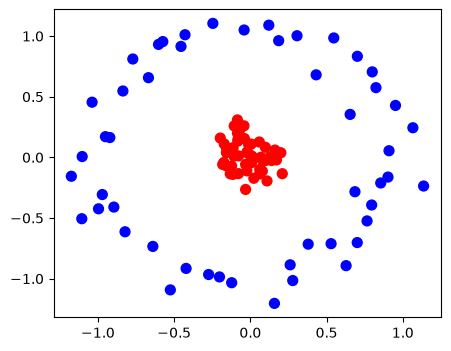

In [6]:
plt.figure(figsize=(5,4))
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr')
plt.show()

### Training **linear SVM** model

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=19)

In [38]:
classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

In [39]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.4

### Function for plotting decision boundary

In [17]:
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, 
                                 stop = X_set[:, 0].max() + 1, 
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1, 
                                 stop = X_set[:, 1].max() + 1, 
                                 step = 0.01))
  
    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(), 
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75, 
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

### Decision boundary for linear SVM model

C:\Users\Gautam Kumar\AppData\Local\Temp\ipykernel_4300\3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


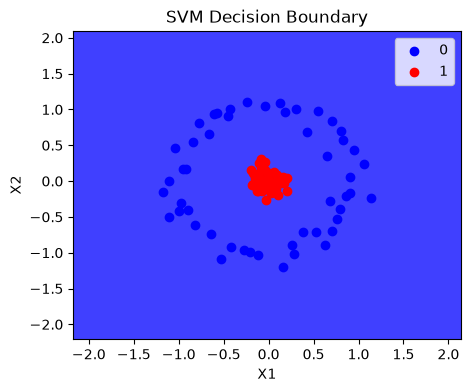

In [40]:
plt.figure(figsize=(5, 4))
plot_decision_boundary(X, y, classifier)
plt.show()

### Function to plot datapoints after transformation from 2-D to 3-D

In [20]:
def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

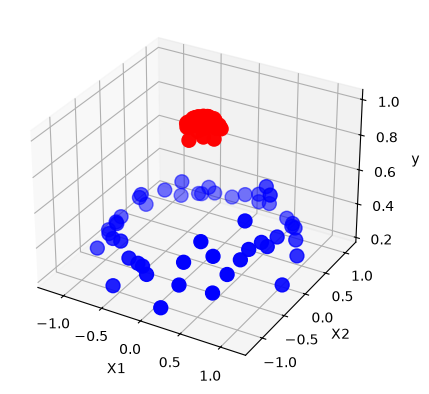

In [21]:
plot_3d_plot(X,y)

### Training SVM model with **Kernal function RBF**

In [22]:
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)

In [23]:
accuracy_score(y_test, y_pred)

1.0

#### Decision boundary of RBF

C:\Users\Gautam Kumar\AppData\Local\Temp\ipykernel_4300\3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


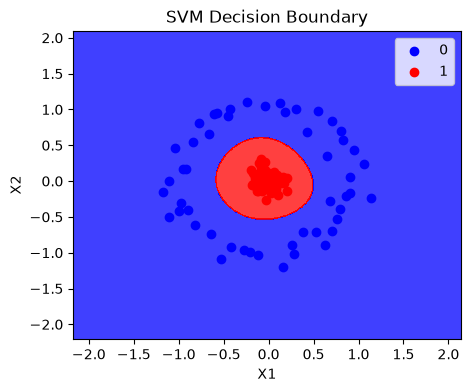

In [25]:
plt.figure(figsize=(5, 4))
plot_decision_boundary(X, y, rbf_classifier)
plt.show()

### Training **Polynomial SVM**

In [26]:
poly_classifier = SVC(kernel="poly",degree=2)
poly_classifier.fit(X_train, y_train)
y_pred = poly_classifier.predict(X_test)

In [27]:
accuracy_score(y_test, y_pred)

1.0

#### Decision boundary of Polynomial SVM

C:\Users\Gautam Kumar\AppData\Local\Temp\ipykernel_4300\3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


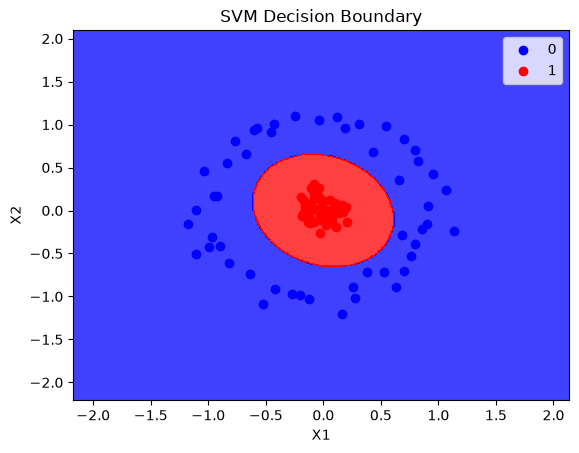

In [28]:
plot_decision_boundary(X, y, poly_classifier)

## Maths behind SVM

In [30]:
X[:10]

array([[ 0.20957685, -0.13449377],
       [-0.07795816, -0.1341625 ],
       [ 0.52958404, -0.71166893],
       [ 0.08899583, -0.02961468],
       [ 0.13913247, -0.02587104],
       [-0.8948867 , -0.40988419],
       [-0.24572621,  1.10470973],
       [-0.19697771,  0.15917618],
       [ 0.18695269,  0.03548139],
       [-0.82166389, -0.61345871]])

In [32]:
np.exp(-(X**2))[:10]

array([[0.95702817, 0.98207404],
       [0.99394096, 0.98216145],
       [0.75543673, 0.60261746],
       [0.99211102, 0.99912336],
       [0.98082831, 0.99933091],
       [0.44895967, 0.84534957],
       [0.94140544, 0.29511694],
       [0.96194287, 0.97498123],
       [0.96565244, 0.99874186],
       [0.50908944, 0.6863747 ]])

In [34]:
np.exp(-(X**2)).sum(1)  # Sum of both the numbers

array([1.93910221, 1.9761024 , 1.35805419, 1.99123438, 1.98015923,
       1.29430924, 1.23652238, 1.9369241 , 1.9643943 , 1.19546414,
       1.9019582 , 1.06898321, 1.98835755, 1.12044505, 1.9675872 ,
       1.98097936, 1.95925783, 1.99756733, 1.26305444, 1.99571208,
       1.97024183, 1.43760394, 1.97022697, 1.45925333, 1.30005112,
       1.97059791, 1.11606099, 1.1359359 , 1.54747068, 1.27628886,
       1.99386268, 1.98115166, 1.26986853, 1.15375178, 1.97058652,
       1.19224445, 1.36223239, 1.98336549, 1.37673301, 1.32872005,
       1.29021198, 1.97996513, 1.43427352, 1.99803484, 1.98350899,
       1.28929047, 1.98798135, 1.32127918, 1.98726949, 1.97472845,
       1.99389783, 1.12469443, 1.41663399, 1.97235224, 1.0625342 ,
       1.12128037, 1.96432578, 1.98798871, 1.99978713, 1.24780481,
       1.20997737, 1.95901503, 1.96857276, 1.98641589, 1.31652125,
       1.33023309, 1.97083137, 1.98058841, 1.53343643, 1.22054992,
       1.3902614 , 1.97552761, 1.40147299, 1.33830257, 1.46508

In [36]:
X_new = np.exp(-(X**2))

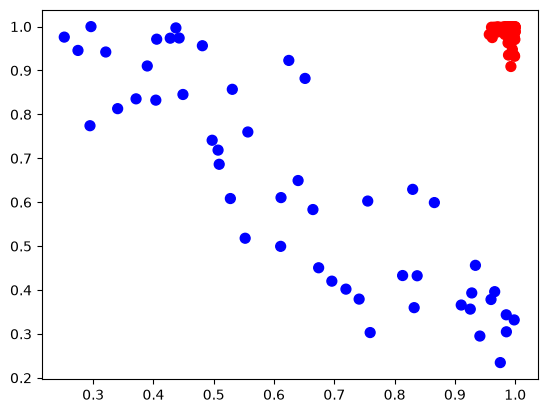

In [37]:
plt.scatter(X_new[:, 0], X_new[:, 1], c=y, s=50, cmap='bwr')